# Advecting particles in ICON output with cell-view velocity reconstruction

Parcels v4 supports unstructured-grid model output through
[uxarray](https://uxarray.readthedocs.io/). This notebook advects particles in a
real [ICON](https://icon-o.gitlab-pages.dkrz.de/icon-o-documentation/) ocean
snapshot and replaces Parcels' default piecewise-constant face interpolator with
the **cell-view linear least-squares reconstruction** of section 2 of *"Simple
reconstruction techniques for triangular meshes"*.

ICON stores the horizontal velocities `u`, `v` at the **centres of triangular
cells** (face-registered data). Parcels' default face interpolator
(`UxConstantFaceConstantZC`) is piecewise constant: every particle in a cell
samples the same velocity and the field jumps across edges. The cell-view
reconstruction instead fits a **linear field inside each cell**, with a slope
obtained by least squares from the neighbouring cells. The slope depends only on
the mesh geometry, so its coefficients are computed once and cached on the grid.
The companion
[FESOM reconstruction notebook](../fesom_reconstruction/fesom_velocity_reconstruction.ipynb)
derives the method and validates it against an analytic field; here we apply the
same kernel to real ICON velocities.

The recipe is:

1. Open the ICON grid and data files with `uxarray`.
2. Rename ICON dimensions to Parcels' UGRID conventions with `parcels.convert.icon_to_ugrid`.
3. Build a `FieldSet` with `parcels.FieldSet.from_ugrid_conventions`.
4. Cache the reconstruction terms on the grid and attach the kernel to `U`, `V`.
5. Release particles and advect, exactly as on a structured grid.

This notebook reads two ICON files from the working directory:

- `icon_levy_grid.nc` — the ICON grid description, trimmed to the variables
  uxarray needs (cell/edge/vertex coordinates and the cell connectivities). This
  ships with the notebook.
- `levy01_r2b8_P1D_3d_20500101T000000Z_10days.nc` — a 10-day snapshot of the
  daily-mean velocities `u`, `v`, `w` from the `levy01` (r2b8) eddy simulation.
  At 288 MB this is too large for git, so it is **not** included here — obtain it
  separately and place it in this directory before running the notebook.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import uxarray as ux
import xarray as xr
from uxarray.constants import INT_FILL_VALUE

import parcels

/tmp/ipykernel_3448573/941190406.py:8: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  import parcels


## The reconstruction kernel

Three ingredients, identical to the FESOM notebook (and mesh-aware: `"flat"` vs
`"spherical"`):

1. `local_offsets` — the local planar offset of a point from a cell centroid.
2. `build_reconstruction_terms` — turns the centroid geometry into the
   least-squares gradient coefficients and **stores them on `uxgrid._ds`**
   together with the neighbour indices and a validity mask, so they travel with
   the grid object every field references.
3. `LinearFaceRecon` — a Parcels scalar interpolator that reads those cached
   terms and evaluates the per-cell linear field at the particle position.

`uxarray` exposes the edge-neighbour set of each cell directly as
`uxgrid.face_face_connectivity` (shape `(n_face, n_max_face_faces)`), with absent
neighbours flagged by `INT_FILL_VALUE`.

In [2]:
DEG2M = 1852.0 * 60.0  # metres per degree (matches Ux_Velocity unit conversion)


def local_offsets(mesh, lon_c, lat_c, lon, lat):
    # local planar offset (dx, dy) of (lon, lat) from centroid (lon_c, lat_c)
    if mesh == "spherical":
        dlon = ((np.asarray(lon) - lon_c + 180.0) % 360.0) - 180.0
        dx = dlon * np.cos(np.deg2rad(lat_c)) * DEG2M
        dy = (np.asarray(lat) - lat_c) * DEG2M
    else:  # flat mesh: coordinates are already a planar (x, y)
        dx = np.asarray(lon) - lon_c
        dy = np.asarray(lat) - lat_c
    return dx, dy


# Compute and attach cell-view least-squares gradient coefficients. Adds to
# uxgrid._ds: gradient_coeff_x/_y, recon_face_neighbors (fill -> self),
# recon_neighbor_mask (1.0 valid / 0.0 absent), all (n_face, n_max_face_faces).
def build_reconstruction_terms(uxgrid, mesh):
    nbr = np.asarray(uxgrid.face_face_connectivity.values)  # (F, K)
    flon = np.asarray(uxgrid.face_lon.values)
    flat = np.asarray(uxgrid.face_lat.values)

    valid = nbr != INT_FILL_VALUE
    nbr_safe = np.where(valid, nbr, 0)

    dx, dy = local_offsets(
        mesh, flon[:, None], flat[:, None], flon[nbr_safe], flat[nbr_safe]
    )
    dx = np.where(valid, dx, 0.0)  # absent -> no contribution
    dy = np.where(valid, dy, 0.0)

    X2 = np.sum(dx * dx, axis=1)
    Y2 = np.sum(dy * dy, axis=1)
    XY = np.sum(dx * dy, axis=1)
    d = X2 * Y2 - XY * XY

    # cells with < 2 independent neighbours give d == 0 -> flat (zero-gradient)
    # fallback, i.e. the original piecewise-constant value.
    ok = d != 0.0
    inv_d = np.where(ok, 1.0 / np.where(ok, d, 1.0), 0.0)

    gx = (dx * Y2[:, None] - dy * XY[:, None]) * inv_d[:, None]
    gy = (dy * X2[:, None] - dx * XY[:, None]) * inv_d[:, None]
    gx = np.where(valid, gx, 0.0)
    gy = np.where(valid, gy, 0.0)

    dims = ("n_face", "n_max_face_faces")
    uxgrid._ds["gradient_coeff_x"] = xr.DataArray(gx, dims=dims)
    uxgrid._ds["gradient_coeff_y"] = xr.DataArray(gy, dims=dims)
    uxgrid._ds["recon_face_neighbors"] = xr.DataArray(nbr_safe, dims=dims)
    uxgrid._ds["recon_neighbor_mask"] = xr.DataArray(
        valid.astype(np.float64), dims=dims
    )
    return uxgrid


# Cell-view linear least-squares reconstruction for face-registered, layer-centered data.
def LinearFaceRecon(particle_positions, grid_positions, field):
    ti = grid_positions["T"]["index"]
    zi = grid_positions["Z"]["index"]
    fi = grid_positions["FACE"]["index"]

    uxg = field.grid.uxgrid
    gx = uxg._ds["gradient_coeff_x"].values[fi]  # (M, K)
    gy = uxg._ds["gradient_coeff_y"].values[fi]
    nb = uxg._ds["recon_face_neighbors"].values[fi]  # (M, K)
    mask = uxg._ds["recon_neighbor_mask"].values[fi]

    uc = field.data.values[ti, zi, fi]  # (M,)
    un = field.data.values[ti[:, None], zi[:, None], nb]  # (M, K)
    du = (un - uc[:, None]) * mask
    ax = np.sum(gx * du, axis=1)
    ay = np.sum(gy * du, axis=1)

    flon = uxg.face_lon.values[fi]
    flat = uxg.face_lat.values[fi]
    dx, dy = local_offsets(
        field.grid._mesh,
        flon,
        flat,
        particle_positions["lon"],
        particle_positions["lat"],
    )
    return uc + ax * dx + ay * dy

## Open the ICON data with `uxarray`

`ux.open_mfdataset(grid_path, data_paths)` reads the ICON grid description and
joins the velocity file onto its grid. The velocity variables keep their ICON
names `u`, `v`, `w`; `cf_xarray` later maps them to Parcels' `U`, `V`, `W` via
their CF standard names.

`open_mfdataset` always returns lazy **dask** arrays. We materialise them in the
next step (see below) — this dataset is small enough that lazy chunking only
adds overhead.

In [3]:
grid_path = "icon_levy_grid.nc"
data_paths = ["levy01_r2b8_P1D_3d_20500101T000000Z_10days.nc"]

ds = ux.open_mfdataset(grid_path, data_paths)
ds

<xarray.UxDataset> Size: 303MB
Dimensions:  (time: 10, n_face: 62324, depth: 40, depth_2: 41)
Coordinates:
  * time     (time) datetime64[ns] 80B 2050-01-02 2050-01-03 ... 2050-01-11
    clon     (n_face) float64 499kB dask.array<chunksize=(62324,), meta=np.ndarray>
    clat     (n_face) float64 499kB dask.array<chunksize=(62324,), meta=np.ndarray>
  * depth    (depth) float64 320B 4.519 14.01 24.45 ... 3.459e+03 3.814e+03
  * depth_2  (depth_2) float64 328B 0.0 9.038 18.98 ... 3.29e+03 3.628e+03 4e+03
Dimensions without coordinates: n_face
Data variables:
    u        (time, depth, n_face) float32 100MB dask.array<chunksize=(1, 40, 62324), meta=np.ndarray>
    v        (time, depth, n_face) float32 100MB dask.array<chunksize=(1, 40, 62324), meta=np.ndarray>
    w        (time, depth_2, n_face) float32 102MB dask.array<chunksize=(1, 41, 62324), meta=np.ndarray>
Attributes:
    CDI:                  Climate Data Interface version 2.6.0 (https://mpime...
    Conventions:          CF-1.6
    number_of_grid_used:  42
    uuidOfHGrid:          2f763e82-6555-11f1-b456-c9f431f678d7
    institution:          Max Planck Institute for Meteorology/Deutscher Wett...
    title:                ICON simulation
    source:               version: 2026.04; revision: icon-2026.04-84-gd5fe82...
    history:              /home/m/m300602/work/proj_idl/icon_03_eddy/icon-mpi...
    references:           see MPIM/DWD publications
    comment:              Nils Brüggemann (m300602) on l10743 (Linux 4.18.0-5...

## Convert to UGRID conventions

Parcels works with a small UGRID-compliant dialect: faces are `n_face`, vertical
centres are `zc`, and vertical interfaces are `zf`. `parcels.convert.icon_to_ugrid`
does the rename in one call. We then drop everything except the velocities `u`,
`v`, `w` and call `ds.load()` to pull them into memory as plain numpy arrays, so
the `FieldSet` builds from a clean, eagerly-loaded dataset.

In [4]:
ds = parcels.convert.icon_to_ugrid(ds)

for var in list(ds):
    if var not in ("u", "v", "w"):
        ds = ds.drop_vars([var])

# Load the velocities eagerly into numpy. The whole dataset is only ~300 MB, so
# dask's lazy chunking buys nothing and is in fact a large slowdown: the face
# interpolator reads field.data.values on every call, which re-runs the full
# dask graph each time. After .load() those reads are cheap numpy views.
ds = ds.load()

print("dims:", dict(ds.sizes))
print("variables:", list(ds))
print("backend:", type(ds["u"].data).__module__)

INFO: Using known vertical dimension mapping: 'depth_2' (interfaces) and 'depth' (centers).


INFO: Renaming vertical dimensions: {'depth_2': 'zf', 'depth': 'zc'}


dims: {'time': 10, 'n_face': 62324, 'zc': 40, 'zf': 41}
variables: ['u', 'v', 'w']
backend: numpy


## Build the `FieldSet`

`parcels.FieldSet.from_ugrid_conventions` detects `U`, `V`, `W`, assigns a
`UxGrid` to each field, and picks an interpolator based on each variable's
location (face- vs. node-registered, centre vs. interface). Use
`mesh="spherical"` so that velocities in m/s are converted to deg/s along the
lon/lat coordinates. `U` and `V` get the face interpolator; `W` gets a
node-registered linear interpolator; the vector fields `UV` and `UVW` are
assembled automatically.

In [5]:
fieldset = parcels.FieldSet.from_ugrid_conventions(ds, mesh="spherical")

for name, field in fieldset.fields.items():
    interp = getattr(field, "interp_method", None)
    interp_name = interp.__name__ if interp is not None else "(vector)"
    print(f"{name:>4s}  ->  {type(field).__name__:<11s}  interp={interp_name}")

INFO: cf_xarray found variable 'w' with CF standard name 'w' in dataset, renamed it to 'W' for Parcels simulation.


INFO: cf_xarray found variable 'u' with CF standard name 'u' in dataset, renamed it to 'U' for Parcels simulation.


INFO: cf_xarray found variable 'v' with CF standard name 'v' in dataset, renamed it to 'V' for Parcels simulation.


   U  ->  Field        interp=UxConstantFaceConstantZC
   V  ->  Field        interp=UxConstantFaceConstantZC
  UV  ->  VectorField  interp=Ux_Velocity
   W  ->  Field        interp=UxConstantFaceLinearZF
 UVW  ->  VectorField  interp=Ux_Velocity


## Attach the reconstruction

We compute the metric terms once on the (spherical) grid shared by the fields,
then swap the face interpolator of `U` and `V` for `LinearFaceRecon`. The
`Ux_Velocity` vector kernel calls our reconstruction for the horizontal
components and handles the m/s -> deg/s conversion.

In [6]:
uxgrid = fieldset.fields["U"].grid.uxgrid
build_reconstruction_terms(uxgrid, mesh="spherical")
print(
    "stored on uxgrid._ds:",
    [v for v in uxgrid._ds.data_vars if v.startswith(("gradient", "recon"))],
)

fieldset.fields["U"].interp_method = LinearFaceRecon
fieldset.fields["V"].interp_method = LinearFaceRecon

stored on uxgrid._ds: ['gradient_coeff_x', 'gradient_coeff_y', 'recon_face_neighbors', 'recon_neighbor_mask']


## Release particles and advect

We seed a grid of particles in the Gulf Stream region of the domain, release them
at 50 m depth, and integrate horizontally with RK4 for two days.

In [7]:
lon_grid, lat_grid = np.meshgrid(
    np.linspace(-80.0, -70.0, 10),
    np.linspace(30.0, 34.0, 4),
)
lon = lon_grid.ravel()
lat = lat_grid.ravel()
z = np.full(lon.size, 50.0)  # release at 50 m depth

pset = parcels.ParticleSet(
    fieldset=fieldset,
    pclass=parcels.Particle,
    lon=lon,
    lat=lat,
    z=z,
)

output_file = parcels.ParticleFile(
    "output-icon.parquet",
    outputdt=np.timedelta64(1, "h"),
    mode="w",
)

pset.execute(
    [parcels.kernels.AdvectionRK4],
    runtime=np.timedelta64(2, "D"),
    dt=np.timedelta64(5, "m"),
    output_file=output_file,
    verbose_progress=True,
)

INFO: Output files are stored in output-icon.parquet


   0%|          | [00:00<?, ?it/s]

Integration time: 2050-01-02T00:00:00   0%|          | [00:00<?, ?it/s]

Integration time: 2050-01-02T00:00:00   0%|          | [00:00<?, ?it/s]

Integration time: 2050-01-02T00:00:00   2%|▏         | [00:00<00:20, 8356.72it/s]

...

Integration time: 2050-01-03T22:00:00  96%|█████████▌| [00:08<00:00, 19790.75it/s]

Integration time: 2050-01-03T22:00:00  98%|█████████▊| [00:08<00:00, 19784.33it/s]

Integration time: 2050-01-03T23:00:00  98%|█████████▊| [00:09<00:00, 19784.33it/s]

Integration time: 2050-01-03T23:00:00 100%|██████████| [00:09<00:00, 20040.16it/s]

Integration time: 2050-01-03T23:00:00 100%|██████████| [00:09<00:00, 19078.22it/s]

## Plot the velocity field and trajectories

We draw the speed at the release depth (≈50 m) as a triangle-coloured background,
then overlay each particle's path (grey lines) and its positions over time
(coloured dots). The view is restricted to the Gulf Stream region where the
particles were released.

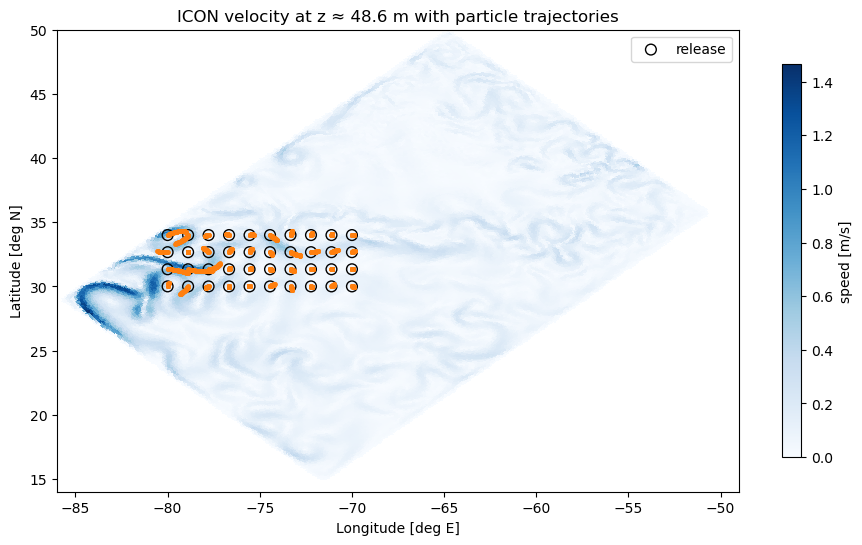

In [8]:
df = parcels.read_particlefile("output-icon.parquet")

triang = mtri.Triangulation(
    ds.uxgrid.node_lon.values,
    ds.uxgrid.node_lat.values,
    triangles=ds.uxgrid.face_node_connectivity.values,
)

depth_idx = int(np.argmin(np.abs(ds.zc.values - 50.0)))
U_face = np.asarray(ds["u"].isel(time=0, zc=depth_idx)).squeeze()
V_face = np.asarray(ds["v"].isel(time=0, zc=depth_idx)).squeeze()
speed = np.hypot(U_face, V_face)

fig, ax = plt.subplots(figsize=(11, 6))
tpc = ax.tripcolor(triang, facecolors=speed, shading="flat", cmap="Blues")
fig.colorbar(tpc, ax=ax, label="speed [m/s]", shrink=0.85)

for traj in df.sort("time").partition_by("particle_id"):
    ax.plot(traj["lon"], traj["lat"], color="0.4", linewidth=0.6, alpha=0.7, zorder=2)
ax.scatter(lon, lat, facecolors="none", edgecolors="k", s=60, label="release", zorder=3)
ax.scatter(df["lon"], df["lat"], s=6, c="tab:orange", zorder=3)

ax.set_xlim(-86, -49)
ax.set_ylim(14, 50)
ax.set_xlabel("Longitude [deg E]")
ax.set_ylabel("Latitude [deg N]")
ax.set_title(
    f"ICON velocity at z ≈ {float(ds.zc.values[depth_idx]):.1f} m with particle trajectories"
)
ax.legend(loc="upper right")
plt.show()

## Summary

- Real ICON face-registered velocities advect in Parcels v4 through `uxarray`
  with the same `open -> convert -> FieldSet -> execute` recipe used for
  structured grids.
- Swapping the default piecewise-constant face interpolator for the cell-view
  `LinearFaceRecon` gives a linear velocity field inside each triangle, fitted by
  least squares to the edge neighbours, with purely geometric coefficients cached
  once on the `uxgrid`.
- See the
  [FESOM reconstruction notebook](../fesom_reconstruction/fesom_velocity_reconstruction.ipynb)
  for the derivation of the method and its accuracy against an analytic field.